In [1]:
!pip install -q optuna
!pip install -q git+https://github.com/RayenSansa03/aeroguard.git@main --force-reinstall --no-deps
!nvidia-smi --query-gpu=name --format=csv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 13.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
name
Tesla T4


In [1]:
from google.colab import drive
drive.mount("/content/drive")

import time
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from aeroguard.donnees_ml import preparer_xy_famille

DOSSIER = "/content/drive/MyDrive/aeroguard"
vols = pd.read_parquet(f"{DOSSIER}/data/processed/vols_ncmapss.parquet")
X_train, fam_train = preparer_xy_famille(vols, "train")
X_val, fam_val = preparer_xy_famille(vols, "val")

encodeur = LabelEncoder().fit(fam_train)
y_train, y_val = encodeur.transform(fam_train), encodeur.transform(fam_val)
familles = list(encodeur.classes_)
moteurs_train = vols.loc[X_train.index, "moteur"].values   # pour grouper par moteur
print(len(X_train), "vols usés au train,", len(set(moteurs_train)), "moteurs")

Mounted at /content/drive
2620 vols usés au train, 49 moteurs


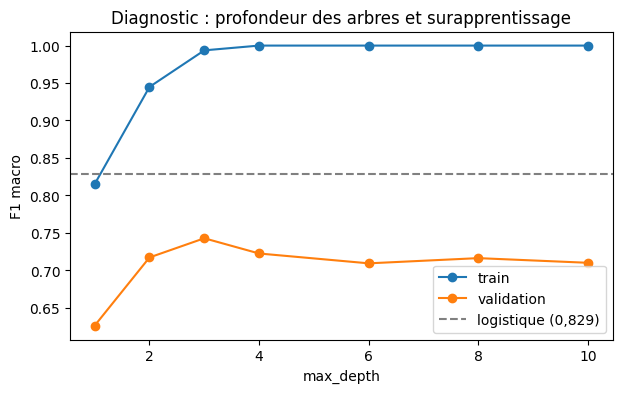

,max_depth,f1_train,f1_val
0,1,0.815,0.626
1,2,0.945,0.717
2,3,0.994,0.743
3,4,1.000,0.722
4,6,1.000,0.709
5,8,1.000,0.716
6,10,1.000,0.710


In [2]:
import matplotlib.pyplot as plt
from aeroguard.modeles import creer_xgboost

lignes = []
for profondeur in [1, 2, 3, 4, 6, 8, 10]:
    m = creer_xgboost("cuda", objective="multi:softprob", eval_metric="mlogloss",
                      early_stopping_rounds=None, n_estimators=300, max_depth=profondeur)
    m.fit(X_train, y_train, sample_weight=compute_sample_weight("balanced", y_train))
    m.set_params(device="cpu")
    lignes.append({"max_depth": profondeur,
                   "f1_train": f1_score(y_train, m.predict(X_train), average="macro"),
                   "f1_val": f1_score(y_val, m.predict(X_val), average="macro")})
courbe = pd.DataFrame(lignes)

plt.figure(figsize=(7, 4))
plt.plot(courbe["max_depth"], courbe["f1_train"], marker="o", label="train")
plt.plot(courbe["max_depth"], courbe["f1_val"], marker="o", label="validation")
plt.axhline(0.829, color="gray", linestyle="--", label="logistique (0,829)")
plt.xlabel("max_depth"); plt.ylabel("F1 macro"); plt.legend()
plt.title("Diagnostic : profondeur des arbres et surapprentissage")
plt.show()
courbe.round(3)

In [3]:
from sklearn.model_selection import StratifiedGroupKFold

plis = list(StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
            .split(X_train, y_train, groups=moteurs_train))

for i, (idx_a, idx_b) in enumerate(plis):
    communs = set(moteurs_train[idx_a]) & set(moteurs_train[idx_b])
    assert not communs, "Un moteur est des deux côtés : fuite !"
    print(f"Pli {i + 1} : {len(set(moteurs_train[idx_b]))} moteurs notés, "
          f"{len(set(y_train[idx_b]))} familles présentes")

Pli 1 : 10 moteurs notés, 6 familles présentes
Pli 2 : 10 moteurs notés, 4 familles présentes
Pli 3 : 10 moteurs notés, 5 familles présentes
Pli 4 : 8 moteurs notés, 4 familles présentes
Pli 5 : 11 moteurs notés, 7 familles présentes


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

def note_cv(fabriquer):
    """F1 macro moyen sur les 5 plis groupés par moteur."""
    notes = []
    for idx_a, idx_b in plis:
        modele = fabriquer()
        poids = compute_sample_weight("balanced", y_train[idx_a])
        if hasattr(modele, "steps"):   # pipeline scikit-learn
            modele.fit(X_train.iloc[idx_a], y_train[idx_a], logisticregression__sample_weight=poids)
        else:                          # XGBoost
            modele.fit(X_train.iloc[idx_a], y_train[idx_a], sample_weight=poids)
            modele.set_params(device="cpu")
        notes.append(f1_score(y_train[idx_b], modele.predict(X_train.iloc[idx_b]), average="macro"))
    return float(np.mean(notes)), float(np.std(notes))

cv_logi = note_cv(lambda: make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000)))
cv_xgb_defaut = note_cv(lambda: creer_xgboost("cuda", objective="multi:softprob",
                                              early_stopping_rounds=None, n_estimators=300))
print(f"Logistique        : {cv_logi[0]:.3f} ± {cv_logi[1]:.3f}")
print(f"XGBoost (défaut)  : {cv_xgb_defaut[0]:.3f} ± {cv_xgb_defaut[1]:.3f}")

Logistique        : 0.571 ± 0.090
XGBoost (défaut)  : 0.521 ± 0.050


In [5]:
import optuna
from aeroguard.modeles import proposer_reglages_xgb

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objectif(trial):
    reglages = proposer_reglages_xgb(trial)
    moyenne, _ = note_cv(lambda: creer_xgboost("cuda", objective="multi:softprob",
                                               early_stopping_rounds=None, **reglages))
    return moyenne

etude = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
debut = time.perf_counter()
etude.optimize(objectif, n_trials=40, show_progress_bar=True)
print(f"Durée : {(time.perf_counter() - debut) / 60:.1f} min")
print("Meilleure note CV :", round(etude.best_value, 3))
print("Meilleurs réglages :", etude.best_params)

  0%|          | 0/40 [00:00<?, ?it/s]

Durée : 8.5 min
Meilleure note CV : 0.53
Meilleurs réglages : {'max_depth': 3, 'learning_rate': 0.18132353625220643, 'n_estimators': 474, 'min_child_weight': 9.848073818583947, 'subsample': 0.9899920302196211, 'colsample_bytree': 0.992818572830793, 'reg_lambda': 0.596678181637187}


/tmp/ipykernel_4423/2952486714.py:3: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  plot_optimization_history(etude)


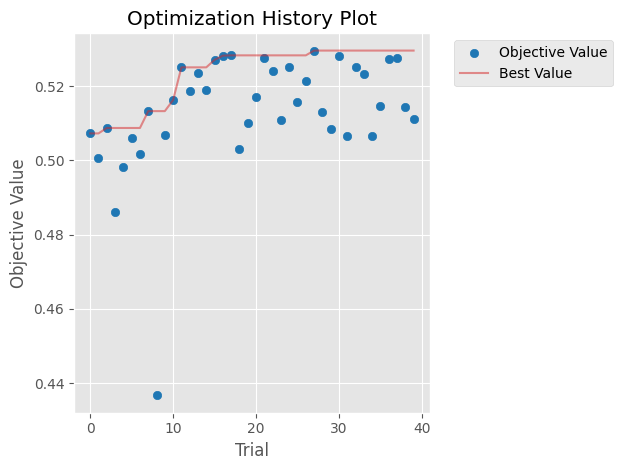

/tmp/ipykernel_4423/2952486714.py:5: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(etude)


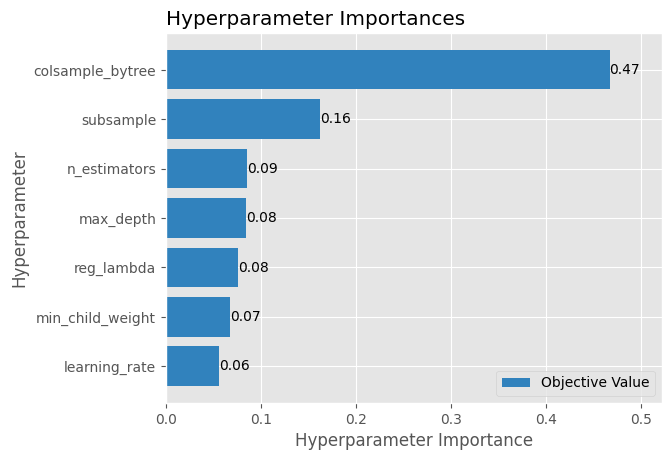

In [6]:
from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances

plot_optimization_history(etude)
plt.show()
plot_param_importances(etude)
plt.show()

In [7]:
from aeroguard.metier import diagnostic_par_moteur

poids = compute_sample_weight("balanced", y_train)
logi = make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000))
logi.fit(X_train, y_train, logisticregression__sample_weight=poids)
xgb_regle = creer_xgboost("cuda", objective="multi:softprob",
                          early_stopping_rounds=None, **etude.best_params)
xgb_regle.fit(X_train, y_train, sample_weight=poids)
xgb_regle.set_params(device="cpu")

moteurs_val = vols.loc[X_val.index, "moteur"]
verite = vols.loc[X_val.index].groupby("moteur")["famille"].first()
resultats = {}
for nom, modele in [("logistique", logi), ("xgboost_regle", xgb_regle)]:
    pred = modele.predict(X_val)
    diag = diagnostic_par_moteur(moteurs_val, encodeur.inverse_transform(pred))
    resultats[nom] = {"exactitude": accuracy_score(y_val, pred),
                      "f1_macro": f1_score(y_val, pred, average="macro"),
                      "moteurs_ok": int((diag == verite).sum())}
resultats["xgboost_defaut (3.3)"] = {"exactitude": 0.730, "f1_macro": 0.721, "moteurs_ok": 9}
pd.DataFrame(resultats).T.round(3)

,exactitude,f1_macro,moteurs_ok
logistique,0.835,0.829,11.0
xgboost_regle,0.734,0.726,9.0
xgboost_defaut (3.3),0.730,0.721,9.0


In [8]:
# Question : peut-on deviner le FICHIER NASA à partir des vols SAINS ?
# Un vol sain ne contient aucune panne. Si on devine le fichier, c'est que les
# features portent une « signature du fichier » que les modèles pourraient exploiter.
sains = vols[(vols["groupe"] == "train") & (vols["hs"] == 1)]
from aeroguard.donnees_ml import colonnes_features
X_s = sains[colonnes_features(vols)]
fichier = LabelEncoder().fit_transform(sains["dataset"])
plis_s = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42).split(
    X_s, fichier, groups=sains["moteur"])

notes = []
for idx_a, idx_b in plis_s:
    m = make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000))
    m.fit(X_s.iloc[idx_a], fichier[idx_a])
    notes.append(accuracy_score(fichier[idx_b], m.predict(X_s.iloc[idx_b])))

hasard = sains["dataset"].value_counts(normalize=True).max()
print(f"Fichiers différents : {sains['dataset'].nunique()}")
print(f"Exactitude pour deviner le fichier (vols sains) : {np.mean(notes):.1%}")
print(f"Référence « toujours le fichier le plus fréquent » : {hasard:.1%}")

Fichiers différents : 9
Exactitude pour deviner le fichier (vols sains) : 56.5%
Référence « toujours le fichier le plus fréquent » : 18.0%


In [9]:
import json
from aeroguard.evaluation import ajouter_au_leaderboard

with open(f"{DOSSIER}/models/xgb_diagnostic_reglages_v3.json", "w") as f:
    json.dump(etude.best_params, f, indent=2)
xgb_regle.save_model(f"{DOSSIER}/models/xgb_diagnostic_regle_v3.json")

chemin = f"{DOSSIER}/results/leaderboard_diagnostic.csv"
ajouter_au_leaderboard(chemin, "xgboost_optuna", {
    "exactitude": resultats["xgboost_regle"]["exactitude"],
    "f1_macro": resultats["xgboost_regle"]["f1_macro"],
    "moteurs_bien_diagnostiques": resultats["xgboost_regle"]["moteurs_ok"],
    "moteurs": 11,
})
pd.read_csv(chemin)

,modele,exactitude,f1_macro,moteurs_bien_diagnostiques,moteurs
0,logistique,0.834783,0.829293,11,11
1,xgboost_gpu,0.730435,0.721062,9,11
2,xgboost_optuna,0.733913,0.726062,9,11
